In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Exploratory Data Analysis - Top Hits Spotify from 2000-2019

**Goals:** 
- Gain an overview of audio features and metadata  
- Assess data quality (missing values, outliers, gaps)  
- Identify patterns and trends in time series
- Find relationships between features
- Group songs based on their audio features

# 1. Questions
- Which Song is the most (un)popular?
- Which genre is the most (un)popular?
- Are there any trends over the years?
- Which artist has the most songs in the data set?
- Which song is the loudest?
- Can songs be grouped?

## Data source and structure

**Data source:**  
- File: "songs_normalize.csv"
- Period of time: 2000-2019
- Measurement interval: yearly
- Measured by: Spotify
- License: CC0 (Public Domain)
- Link: https://www.kaggle.com/datasets/paradisejoy/top-hits-spotify-from-20002019/

**Description:**
- This data set contains audio statistics on the top 2000 tracks on Spotify from 2000-2019.

**Datenstructure:**
- Format: CSV-File
- "artist": Name of artist, stored as object
- "song": Title of song, stored as object
- "duration_ms": Duration of song in ms, stored as integer
- "explicit": Whether the song contains explicit language, stored as a boolean
- "year": Release date of the song, stored as an integer
- "popularity": The popularity of the song, stored as an integer
- "danceability": How suitable the song is for dancing, stored as a float
- "energy": A perceptual measure of intensity and activity of the song, stored as a float
- "key": The musical key of the song. Integers map to pitches using standard pitch class notation. If no key was detected, the value is -1. Stored as an integer
- "loudness": The average loudness of the song in decibels, stored as a float
- "mode": The modality of the song. Major is represented by 1 and minor by 0, stored as an integer
- "speechiness": The presence of spoken words in the track. The closer to 1, the more speech-like the recording, stored as a float
- "acousticness": The likelihood that the track is acoustic. The closer this value is to 1, the higher the probability, stored as a float
- "instrumentalness": The likelihood that the track contains no vocals. The closer to 1, the more likely the track has no vocal content, stored as a float
- "liveness": The probability that the track was performed live. A value above 0.8 indicates a high likelihood of a live performance, stored as a float
- "valence": A measure describing the musical positivity conveyed by the track. The closer to 1, the more positive the music sounds, stored as a float
- "tempo": The estimated tempo of the track in BPM, stored as a float
- "genre": The genre of the song, stored as an object

# 2. Loading data and first overview

In [2]:
df = pd.read_csv("songs_normalize.csv")

print("Form of the data set:", df.shape)
display(df.head())

Form of the data set: (2000, 18)


,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


In [3]:
print("\nData information:")
display(df.info())


Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   object 
 1   song              2000 non-null   object 
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 

None

In [4]:
print("\nStatistical base information:")
desc = df.describe()
display(df.describe())


Statistical base information:


,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,228748.124500,2009.49400,59.872500,0.667438,0.720366,5.378000,-5.512434,0.553500,0.103568,0.128955,0.015226,0.181216,0.551690,120.122558
std,39136.569008,5.85996,21.335577,0.140416,0.152745,3.615059,1.933482,0.497254,0.096159,0.173346,0.087771,0.140669,0.220864,26.967112
min,113000.000000,1998.00000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203580.000000,2004.00000,56.000000,0.581000,0.622000,2.000000,-6.490250,0.000000,0.039600,0.014000,0.000000,0.088100,0.386750,98.985750
50%,223279.500000,2010.00000,65.500000,0.676000,0.736000,6.000000,-5.285000,1.000000,0.059850,0.055700,0.000000,0.124000,0.557500,120.021500
75%,248133.000000,2015.00000,73.000000,0.764000,0.839000,8.000000,-4.167750,1.000000,0.129000,0.176250,0.000068,0.241000,0.730000,134.265500
max,484146.000000,2020.00000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


In [5]:
display(df.columns)

Index(['artist', 'song', 'duration_ms', 'explicit', 'year', 'popularity',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'genre'],
      dtype='object')

# 3. Checking data quality

In [6]:
print("Checking for missing values:")
df.isnull().sum()

Checking for missing values:


artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

In [7]:
print("Checking for duplicate values:")
display(df.duplicated().sum())

#remove them if needed:
df = df.drop_duplicates()

Checking for duplicate values:


np.int64(59)

In [8]:
#Plausibility checks
#Check expected value ranges
ranges = {
    "danceability": (0, 1),
    "energy": (0, 1),
    "speechiness": (0, 1),
    "acousticness": (0, 1),
    "instrumentalness": (0, 1),
    "liveness": (0, 1),
    "valence": (0, 1),
    "tempo": (30, 250),       
    "loudness": (-60, 0),     # dB
    "duration_ms": (30_000, 1_000_000)
}

for col, (min_val, max_val) in ranges.items():
    if col in df.columns:
        invalid = df[(df[col] < min_val) | (df[col] > max_val)]
        print(f"{col}: {len(invalid)} invalid values")

danceability: 0 invalid values
energy: 0 invalid values
speechiness: 0 invalid values
acousticness: 0 invalid values
instrumentalness: 0 invalid values
liveness: 0 invalid values
valence: 0 invalid values
tempo: 0 invalid values
loudness: 0 invalid values
duration_ms: 0 invalid values


# 4. Datacleansing

**Since no implausible values were found, no values need to be removed.**

In [9]:
#Summarizing rare genres
genre_counts = df["genre"].value_counts()
rare_genres = genre_counts[genre_counts < 50].index

df["genre"] = df["genre"].replace(rare_genres, "other")

In [10]:
#Filter the years in a useful manner:
df = df[df["year"].between(1950, 2025)]

In [11]:
#Quality check
print("New form:", df.shape)
print("Missing values:")
display(df.isna().sum())

print("Duplicates:")
display(df.duplicated().sum())

display(df.describe())

New form: (1941, 18)
Missing values:


artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

Duplicates:


np.int64(0)

,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,228594.973725,2009.520350,59.633179,0.667814,0.721549,5.369397,-5.514082,0.553323,0.103783,0.128173,0.015372,0.181726,0.552966,120.158442
std,39249.796103,5.875532,21.501053,0.140608,0.152872,3.615270,1.938950,0.497277,0.096148,0.172584,0.088371,0.140910,0.220845,26.990475
min,113000.000000,1998.000000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203506.000000,2004.000000,56.000000,0.581000,0.624000,2.000000,-6.490000,0.000000,0.039700,0.013500,0.000000,0.088400,0.390000,98.986000
50%,223186.000000,2010.000000,65.000000,0.676000,0.739000,6.000000,-5.285000,1.000000,0.061000,0.055800,0.000000,0.124000,0.560000,120.028000
75%,247946.000000,2015.000000,73.000000,0.765000,0.840000,8.000000,-4.168000,1.000000,0.129000,0.176000,0.000069,0.242000,0.731000,134.199000
max,484146.000000,2020.000000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


In [12]:
print("First look after the data cleansing:")
display(df)

First look after the data cleansing:


,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,other
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,other
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,other
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Jonas Brothers,Sucker,181026,False,2019,79,0.842,0.734,1,-5.065,0,0.0588,0.0427,0.000000,0.1060,0.952,137.958,pop
1996,Taylor Swift,Cruel Summer,178426,False,2019,78,0.552,0.702,9,-5.707,1,0.1570,0.1170,0.000021,0.1050,0.564,169.994,pop
1997,Blanco Brown,The Git Up,200593,False,2019,69,0.847,0.678,9,-8.635,1,0.1090,0.0669,0.000000,0.2740,0.811,97.984,other
1998,Sam Smith,Dancing With A Stranger (with Normani),171029,False,2019,75,0.741,0.520,8,-7.513,1,0.0656,0.4500,0.000002,0.2220,0.347,102.998,pop


# 5. Univariate Analysis and Outliers

In [13]:
#which song is the most popular song?
df.loc[df["popularity"].idxmax(), ["song","popularity", "artist"]]

song            Sweater Weather
popularity                   89
artist        The Neighbourhood
Name: 1322, dtype: object

The most popular song is "Sweater Weather" by The Neighbourhood and the least popular song is "Go Let It Out" by Oasis.

In [14]:
df.loc[df["popularity"].idxmin(), ["song","popularity", "artist"]]

song          Go Let It Out
popularity                0
artist                Oasis
Name: 59, dtype: object

The least popular song is "Go Let It Out" by Oasis.

In [15]:
df.loc[df["loudness"].idxmax(), ["song","artist","loudness"]]

song        In For The Kill
artist              La Roux
loudness             -0.276
Name: 971, dtype: object

The loudest song is "In For The Kill" by La Roux with a loudness of -0.276 decibel.

Histograms for every numeric feature:


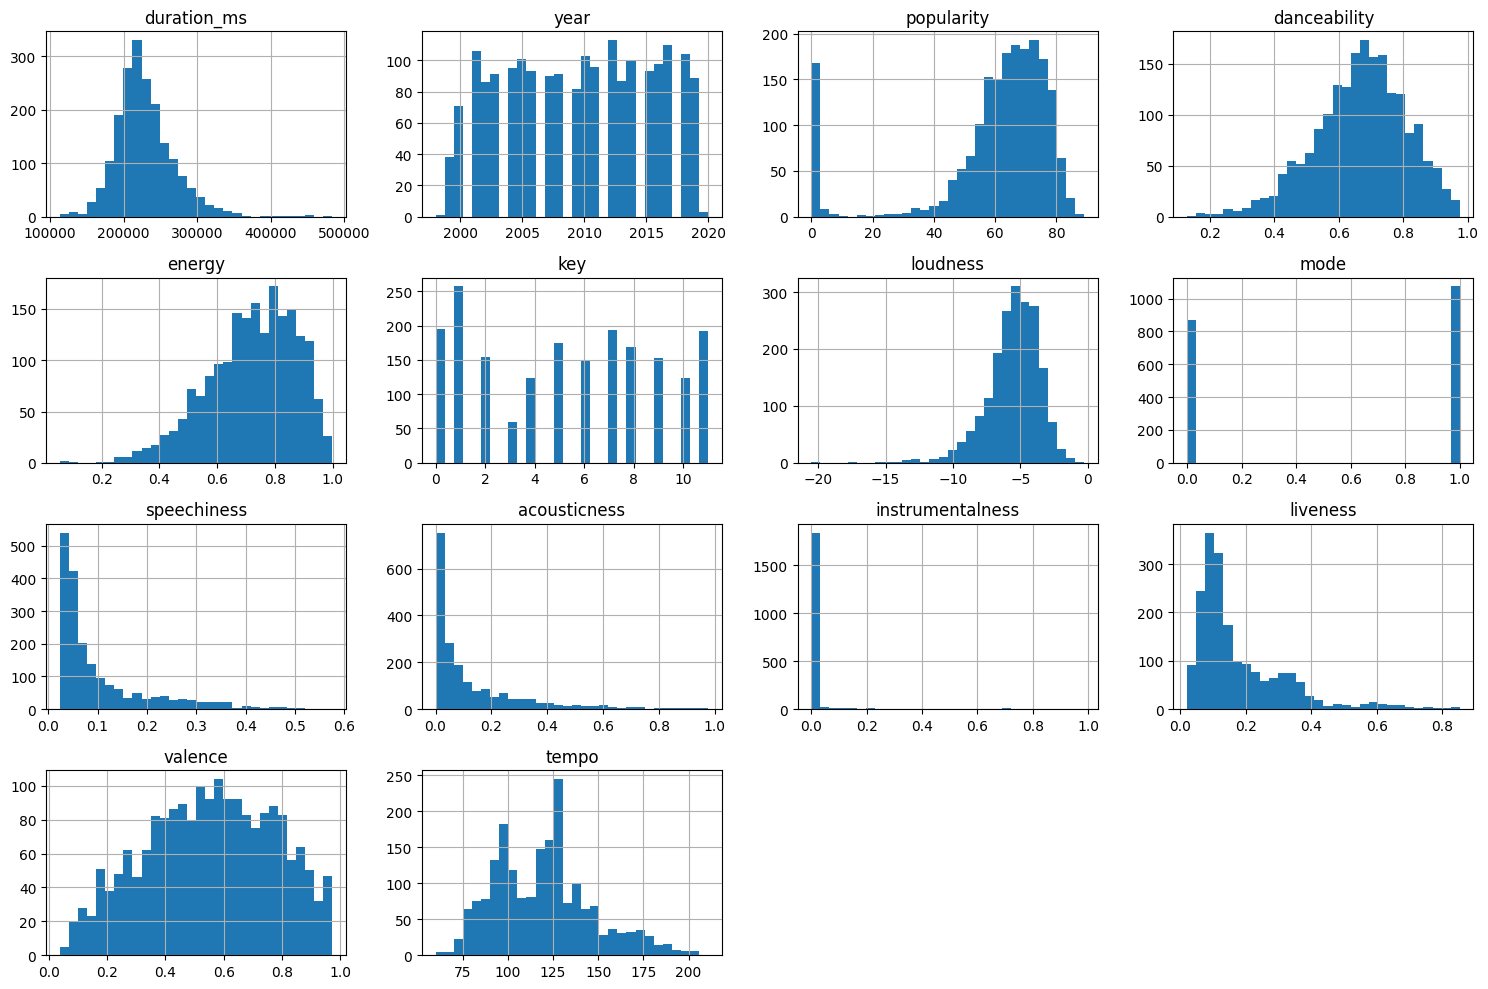

In [16]:
print("Histograms for every numeric feature:")
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

**Interpretation:**
- Most songs have a duration of around 220000 ms, or around 3 min and 40 minutes.
- Most songs were released in the year 2012 and the fewest in the year 1995.
- Most songs have a popularity rating of 60-80 while there are many songs that have a rating of 0.
- Majority of songs have a danceability rating of higher than 0.6, thus making most songs suitable for dancing.
- Most songs have an energy rating of over 0.6, thus most songs have perceptual measure of intensity and activity.
- Vast majority songs have a loudness rating of around -5 db, thus making most songs quite loud.
- A bit more songs are in major modality than in minor modality.
- Vast majority of songs have a speechiness rating of less than 0.1, thus making most music non-vocal.
- Most songs have a acousticness rating of less than 0.2, making most songs less likely to be acoustic.
- Almost all songs have an instrumentalness rating of less than 0.2, thus most songs have little to no vocals.
- Majority of songs have  a liveness rating of 0.2, that concludes that most songs were not recorded during a live concert.
- In valence rating, there is a normal distribution, with a slight tendency to higher values. Thus, the songs sound slightly more positively than negatively.
- In tempo rating, most songs have a rating of less than 130.

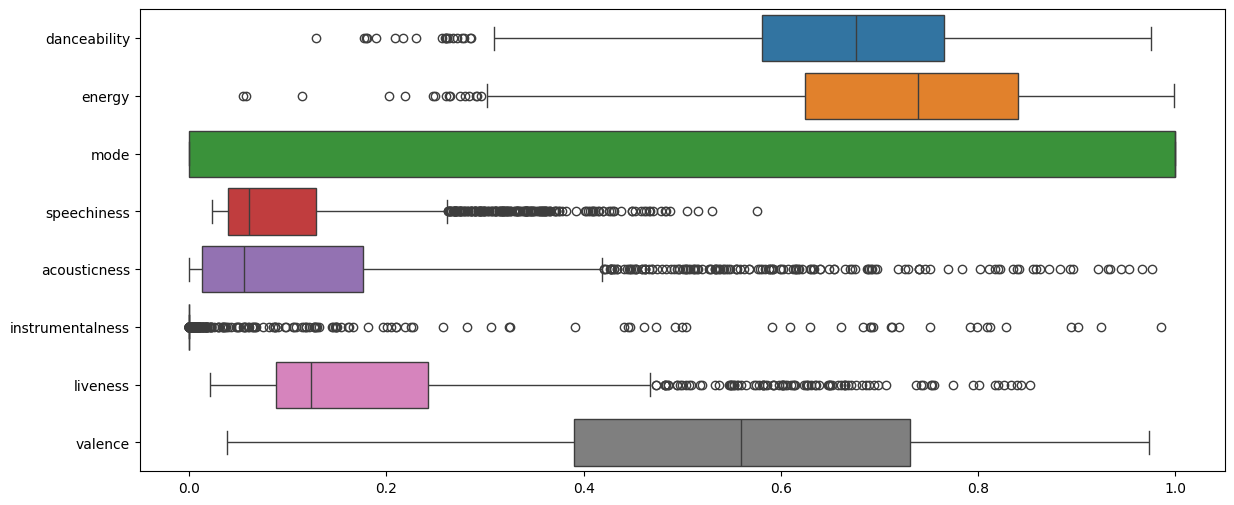

In [17]:
tiny_features = [
    "danceability", "energy", "mode", 
    "speechiness", "acousticness", "instrumentalness",
     "liveness", "valence"
]

plt.figure(figsize=(14,6))
sns.boxplot(data=df[tiny_features], orient="h")
plt.show()

### Interpretation: 
- The features "mode" and "valence" have no outliers whatsoever and have similar sized variability.  
- Whereas "danceability" and "energy" have some outliers and similar sized variability. That means that most songs are quite "danceable" and have intensity and activity. There is high varability in both of these features.
- "speechiness", "acousticness", "instrumentalness" and "liveness" have the most outliers. The median, and first and third quartile of "speechiness" are below 0.2, that conveys that most songs are less likely to be speech-like and have low variability. 
- In "acousticness", the median, and first and third quartile are below 0.2 as well. That means that most songs are less likely to be acoustic. There is moderate variability.
- Besides the outliers, most songs have an "instrumentalness" value of around 0, that concludes that most songs have at least some vocals. 
- In "liveness" the third quartile is a bit higher than 0.2 and have moderate variability. That shows that most songs are less likely to be performed live.

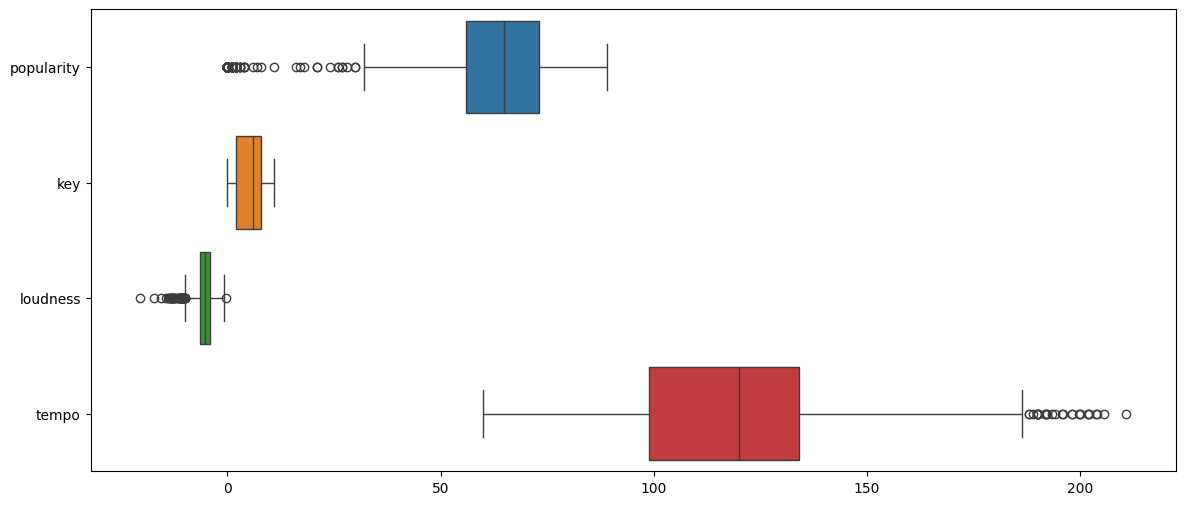

In [18]:
features = [
    "popularity", "key", "loudness", "tempo"
]

plt.figure(figsize=(14,6))
sns.boxplot(data=df[features], orient="h")
plt.show()

### Interpretation:
- "key" and "loudness" have very low variabilites. "key" has no outliers and "loudness" has few outliers.
- "loudness" has low first whisker, that means most songs are quite loud.
-  "popularity" and "tempo" have not many outliers. "popularity" has a first quartile of over 50, thus making most songs quite popular.

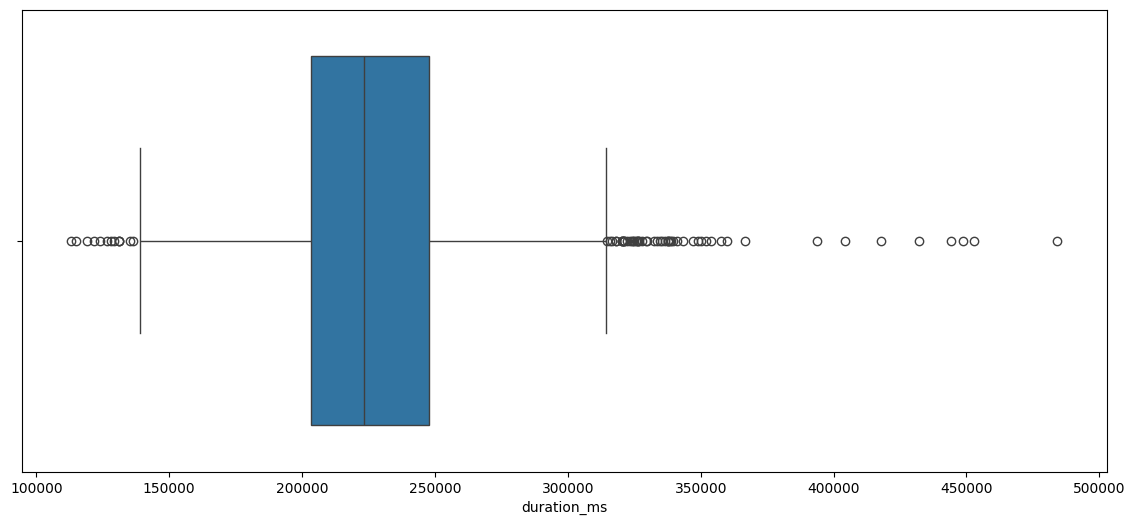

In [19]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df["duration_ms"], orient="h")
plt.show()

### Interpretation:
- Few songs are longer than 315000 ms (5.25 min) or shorter than 140000 ms (2.33 min). 

# 6. Bivariate Analysis

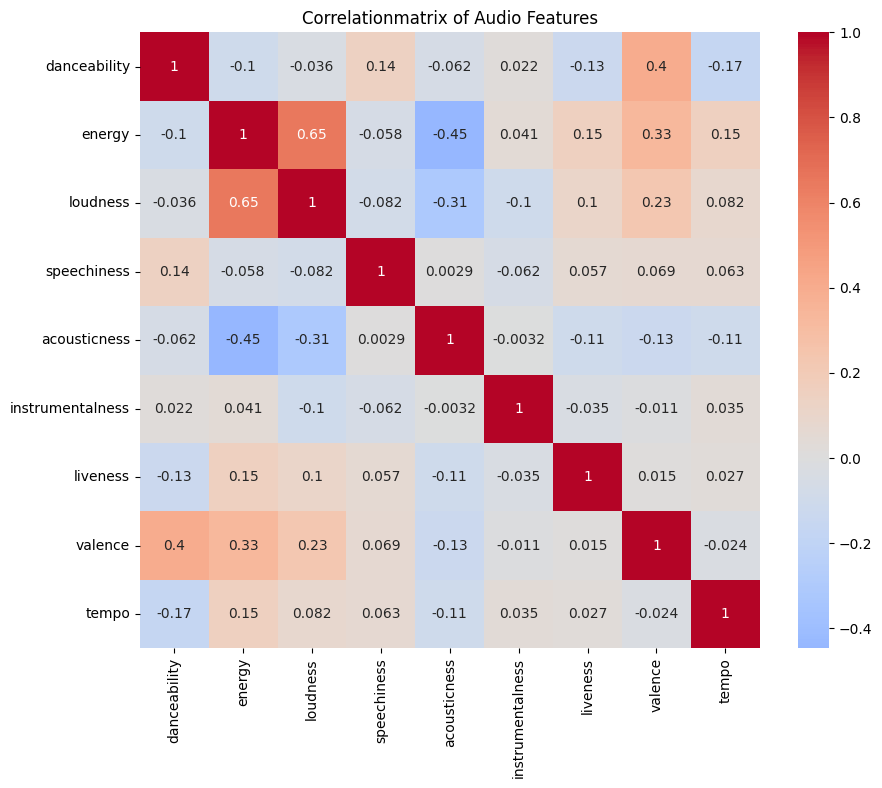

In [20]:
audio_features = [
    "danceability","energy","loudness",
    "speechiness","acousticness",
    "instrumentalness","liveness",
    "valence","tempo"
]

plt.figure(figsize=(10,8))
sns.heatmap(df[audio_features].corr(), cmap="coolwarm", center=0, annot=True)
plt.title("Correlationmatrix of Audio Features")
plt.show()

### Interpretation: 
According to the heatmap, first conclusions are:
- "loudness" and "energy" have relevant correlation.
- "acousticness" with "energy" and "loudness" have weak correlation.
- "valence" with "danceability" and "energy" have weak correlation.
- Everything else has none to irrelevant correlation.

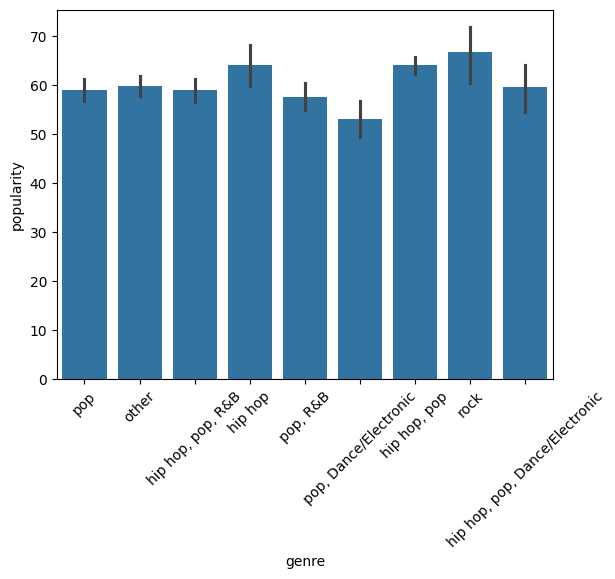

In [21]:
df.groupby("genre")["popularity"].mean().sort_values(ascending=False)

sns.barplot(
    data=df,
    x="genre",
    y="popularity",
    estimator=np.mean
)
plt.xticks(rotation=45)
plt.show()

## Interpretation: 
- "rock", "hip hop" and "hip hop, pop" are the most popular genres
- "pop, Dance/Electronic" and "pop, R&B" are the least popular genres

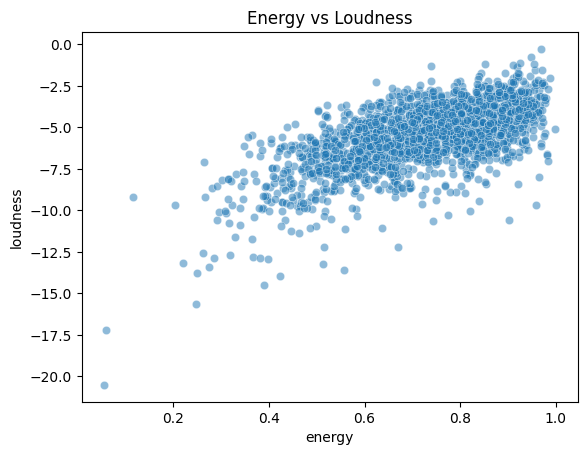

In [22]:
sns.scatterplot(data=df, x="energy", y="loudness", alpha=0.5)
plt.title("Energy vs Loudness")
plt.show()

A slight but noticeable correlation between energy and loudness can be observed.

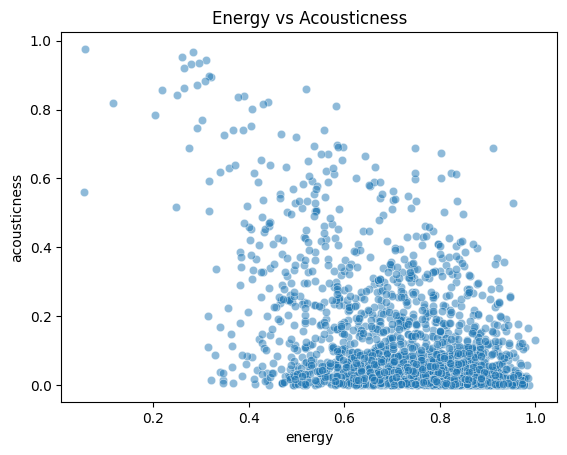

In [23]:
sns.scatterplot(data=df, x="energy", y="acousticness", alpha=0.5)
plt.title("Energy vs Acousticness")
plt.show()

A very slight negative correlation on few songs can be observed.

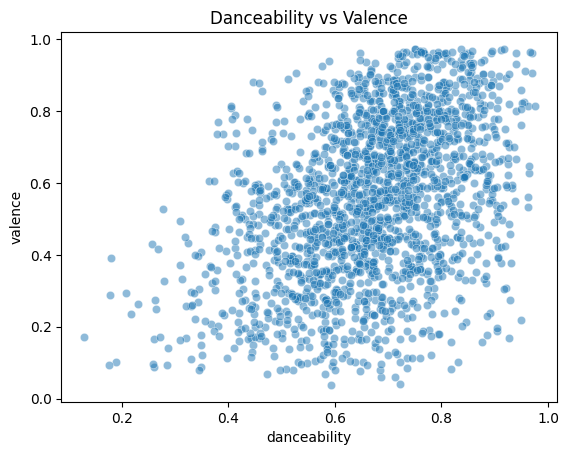

In [24]:
sns.scatterplot(data=df, x="danceability", y="valence", alpha=0.5)
plt.title("Danceability vs Valence")
plt.show()

A slight but noticeable correlation between danceability and valence can be observed.

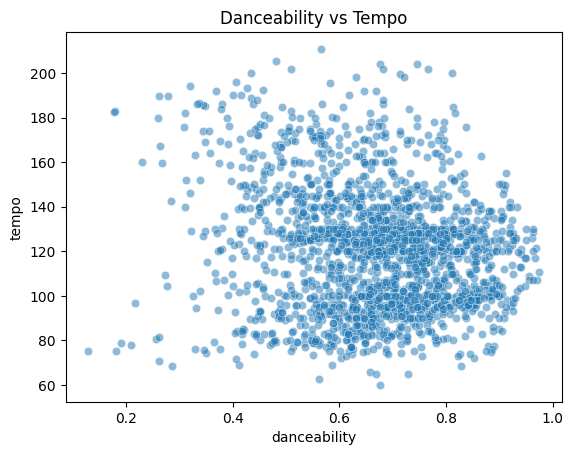

In [25]:
sns.scatterplot(data=df, x="danceability", y="tempo", alpha=0.5)
plt.title("Danceability vs Tempo")
plt.show()

Very little to no correlation between Danceability and Tempo can be observed.

# 7. Categorial Analysis

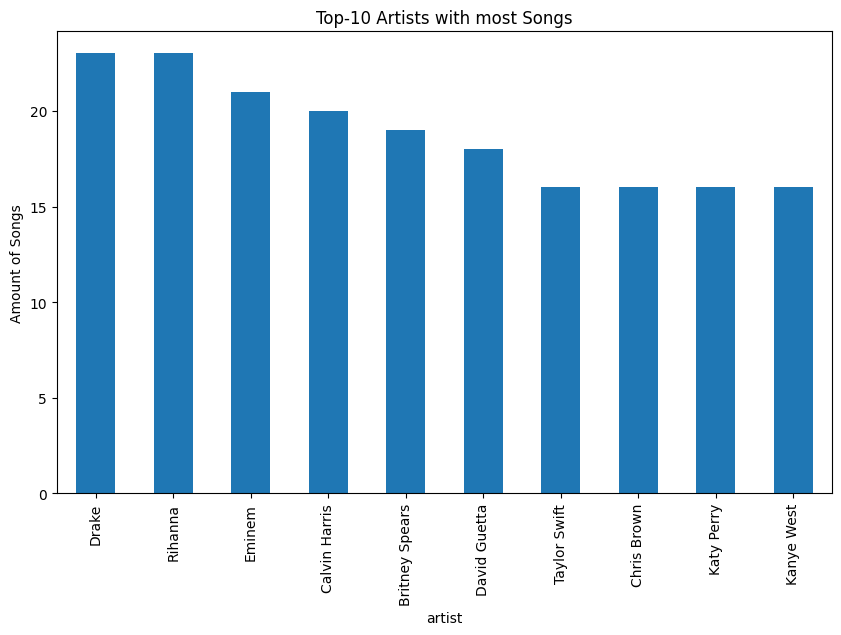

In [26]:
plt.figure(figsize=(10,6))
df["artist"].value_counts().head(10).plot(kind="bar")
plt.title("Top-10 Artists with most Songs")
plt.ylabel("Amount of Songs")
plt.show()

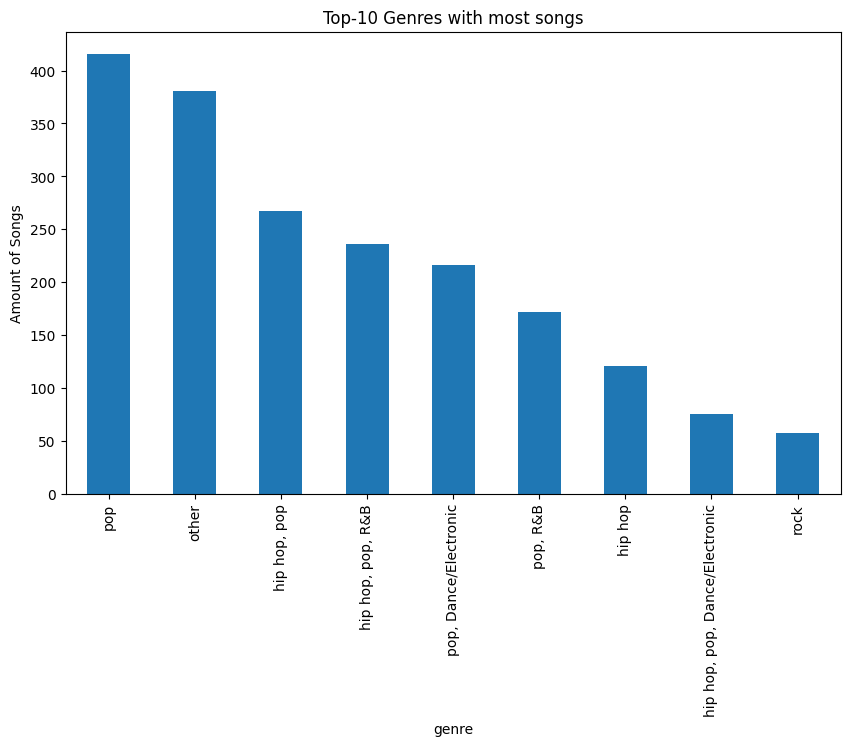

In [27]:
plt.figure(figsize=(10, 6))
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top-10 Genres with most songs")
plt.ylabel("Amount of Songs")
plt.show()

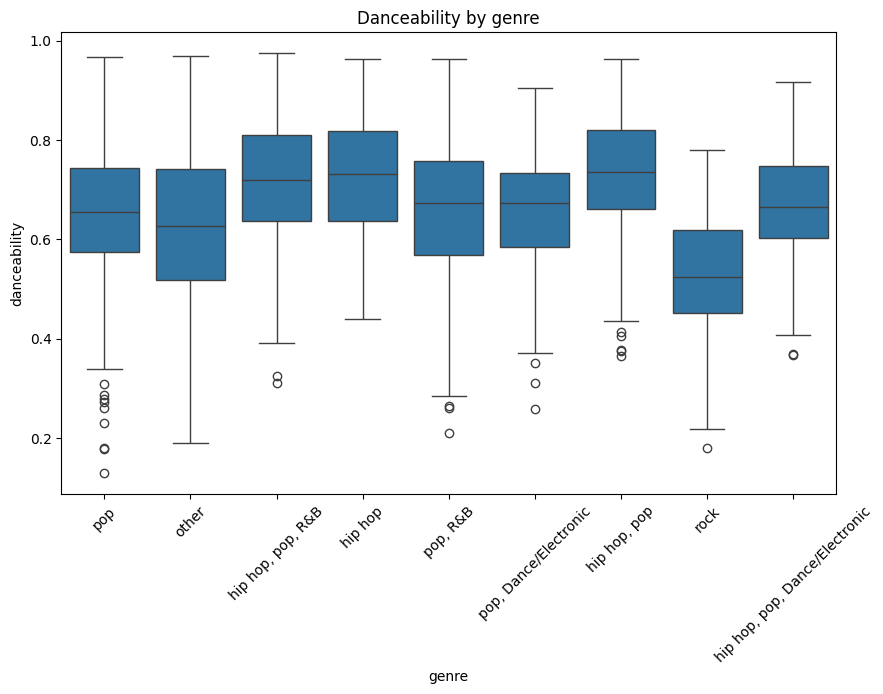

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='genre', y='danceability')
plt.xticks(rotation=45)
plt.title("Danceability by genre")
plt.show()

"hip hop" and "hip hop, pop" have the highest median and third quartile compared to every other genre. "rock" has the lowest median and lowest third quartile. "other" are consistent and they have songs with low danceability songs with high danceability.

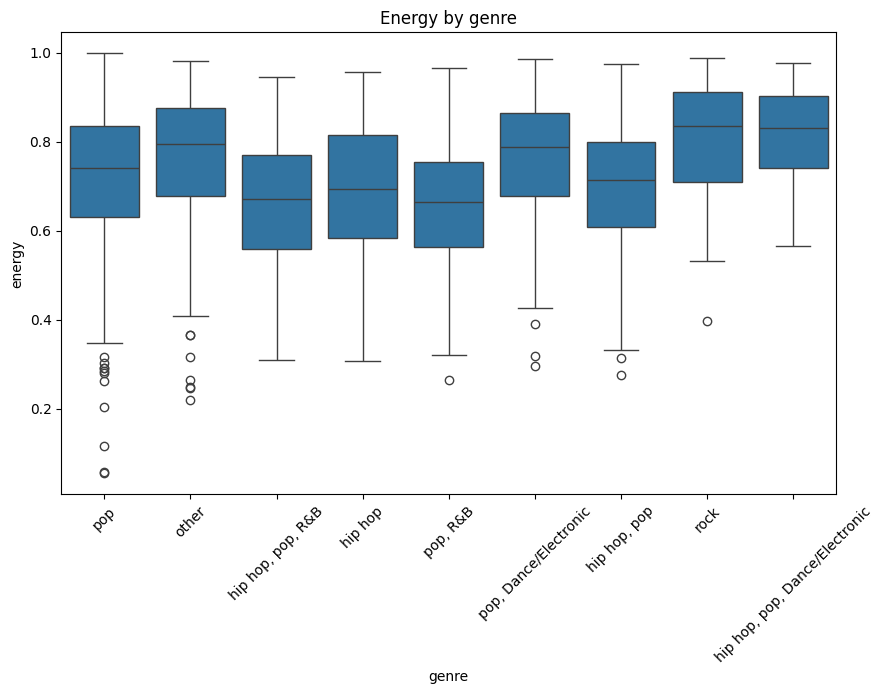

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='genre', y='energy')
plt.xticks(rotation=45)
plt.title("Energy by genre")
plt.show()

"pop" songs have the highest and lowest energy value, whereas "other" and "pop, Dance/Electronic" have the highest median and highest third quartile. "pop" has also the most outliers. "hip hop, pop, R&B" and "pop, R&B" have the lowest median.

Text(0.5, 1.0, 'Distribution of songs over years')

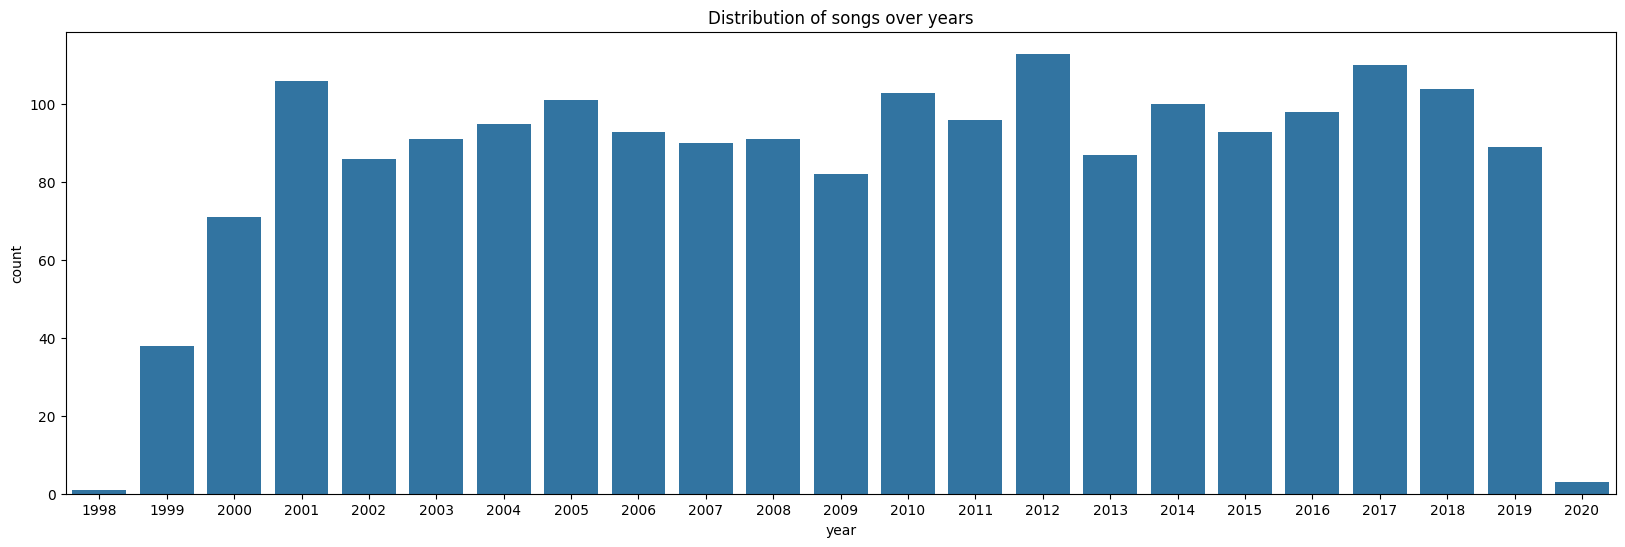

In [30]:
plt.figure(figsize=(20, 6))
sns.countplot(x='year', data=df)
plt.title("Distribution of songs over years")

Most songs are distributed in 2012, 2001 and 2017. For most of the time, at least 80 songs were released each year. The least songs were released in 1998, 1999 and 2020. 

# 8. Development of Features over time

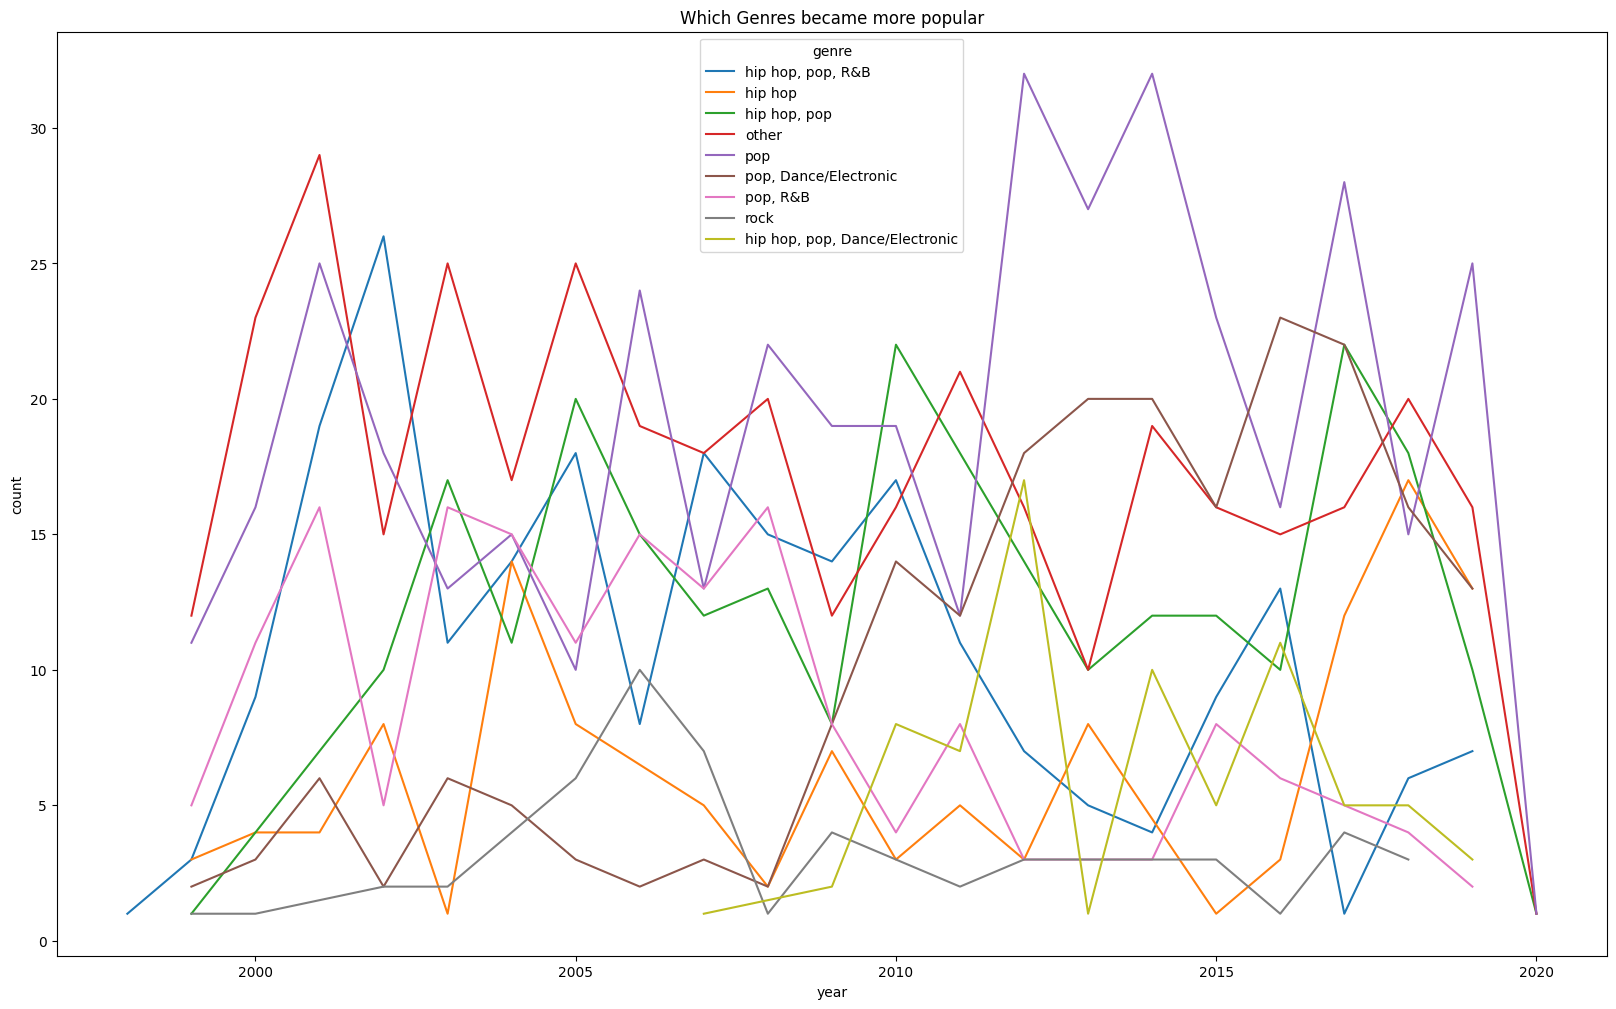

In [31]:
plt.figure(figsize=(20, 12))
genre_trend = df.groupby(["year","genre"]).size().reset_index(name="count")

sns.lineplot(data=genre_trend, x="year", y="count", hue="genre")
plt.title("Which Genres became more popular")
plt.show()

### Interpretation:
"pop" and any form of hip hop are among the most popular genres over the years. "rock" is among the least popular genres over the years. "pop, Dance/Electronic" started to become popular in 2010.

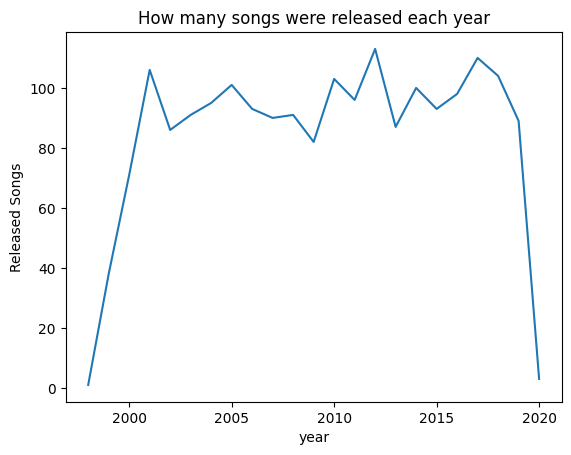

In [32]:
songs_per_year = df.groupby("year").size()

sns.lineplot(x=songs_per_year.index, y=songs_per_year.values)
plt.title("How many songs were released each year")
plt.ylabel("Released Songs")
plt.show()

Most songs were released in 2012 and the least songs in 2009. From 2000 to 2019, at least 80 songs were released each year.

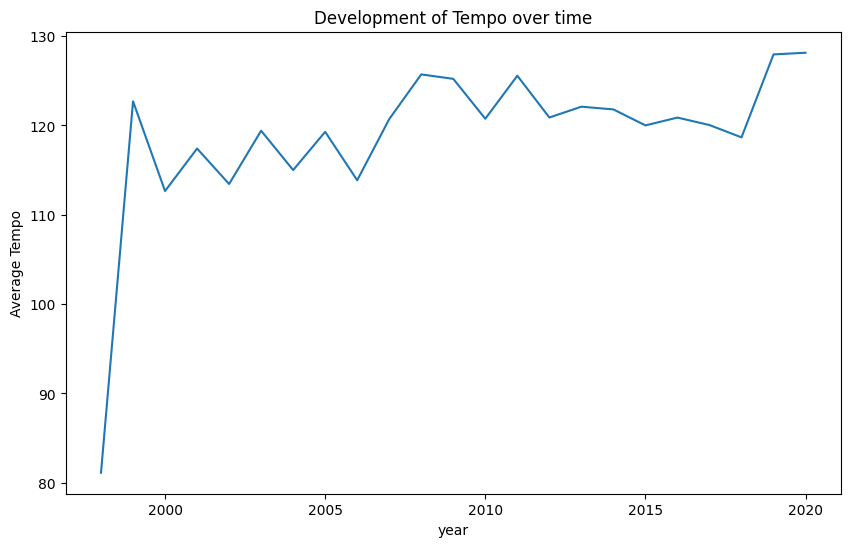

In [33]:
trend = df.groupby("year")["tempo"].mean()

trend.plot(figsize=(10,6))
plt.title("Development of Tempo over time")
plt.ylabel("Average Tempo")
plt.show()

In 2000, tempo alternated between increasing and declining up until 2006 where it barely increased compared to 2000. After 2006 an increase until 2012 can be observed. After 2012 there is a slight decline until 2018 where it started to increase again.

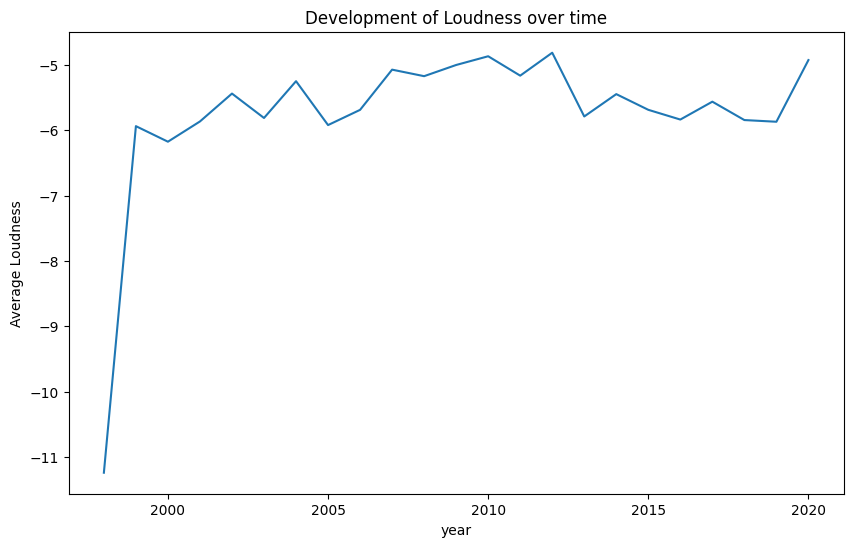

In [34]:
trend = df.groupby("year")["loudness"].mean()

trend.plot(figsize=(10,6))
plt.ylabel("Average Loudness")
plt.title("Development of Loudness over time") #The closer to 0, the louder the songs
plt.show()

Loudness started at around -6 db and had a slow and steady increase until 2011. With some years having slight decrease compared to prior year.
Loudness peaked 2011 with -5 db and had a slight decline until 2020 where it increased noticeably. 

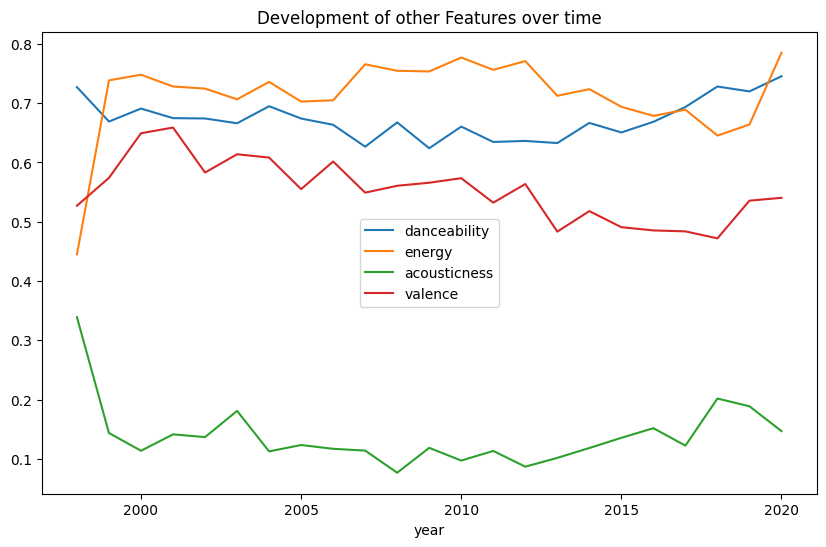

In [35]:
features = ["danceability","energy","acousticness","valence"]

trend = df.groupby("year")[features].mean()

trend.plot(figsize=(10,6))
plt.title("Development of other Features over time")
plt.show()

Danceability had a steady decline until 2011 and after that had a steady increase.
Energy had a very slight decline until 2006 and had an increase from 2007 up until 2012 and then declined until 2020.
Acousticness had a slow decline up until 2012 and then increased until 2018.
Valence peaked in 2001 and declined completely after that and had some increases compared to prior years.

# 9. Summary of EDA

- In this exploratory data analysis, the Spotify dataset was examined to gain a better understanding of the audio features and their relationships. The dataset contains songs with various audio features such as "loudness" and "energy", as well as metadata like "genre" and "popularity". Since most variables are numerical, they are well suited for statistical analysis. Most audio features, such as "danceability" and "energy", fall within the medium to high range, while some variables, like "speechiness", are generally in the lower range.

- Several relationships between features can be observed. For example, there is a positive correlation between "energy" and "loudness", as well as a slight negative correlation between "danceability" and "valence".

- Differences in audio features can be observed across genres. Some genres exhibit higher average values of energy or danceability, indicating distinct musical characteristics.

- Changes in audio features can be observed over the years. For instance, there is a trend toward higher tempo and lower valence, which may suggest increasing electronic influences in music and emerging trends.

- Popularity varies across genres. Some genres have higher average popularity scores, indicating differences in market preferences.

- Some outliers were identified; however, they appear plausible and were not removed.

- Overall, the analysis shows that audio features are well suited to characterize and distinguish songs from one another. This provides a solid foundation for further analyses, such as clustering, where songs can be grouped based on their characteristics.

# 10. Preparations for Clustering
The aim of this section is to group songs based on their audio features. Based on the previous exploratory analysis, the data exhibit distinct patterns that may indicate the presence of natural groupings.

Therefore, a clustering method (K-Means) is applied to automatically identify similar songs.

In [36]:
cl_features = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness', 'liveness', 'speechiness']

X = df[cl_features]
#Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0, 0.5, 'Inertia')

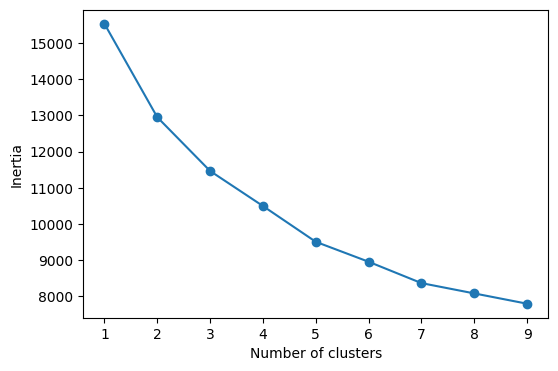

In [37]:
#Elbow Method to find number of clusters
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

The chosen k=3.

# 11. Clustering

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster'].value_counts()

cluster
1    841
0    670
2    430
Name: count, dtype: int64

In [39]:
df.groupby('cluster')[cl_features].mean()

,danceability,energy,valence,tempo,loudness,acousticness,liveness,speechiness
cluster,,,,,,,,
0,0.563200,0.790924,0.440602,132.373910,-4.830581,0.058933,0.229209,0.090605
1,0.756608,0.766659,0.719929,114.955369,-4.950990,0.098107,0.159375,0.110544
2,0.657153,0.525226,0.401497,111.301281,-7.680377,0.294861,0.151457,0.111093


In [40]:
display(df)

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre,cluster
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop,1
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,other,0
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,other,2
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,other,0
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Jonas Brothers,Sucker,181026,False,2019,79,0.842,0.734,1,-5.065,0,0.0588,0.0427,0.000000,0.1060,0.952,137.958,pop,1
1996,Taylor Swift,Cruel Summer,178426,False,2019,78,0.552,0.702,9,-5.707,1,0.1570,0.1170,0.000021,0.1050,0.564,169.994,pop,0
1997,Blanco Brown,The Git Up,200593,False,2019,69,0.847,0.678,9,-8.635,1,0.1090,0.0669,0.000000,0.2740,0.811,97.984,other,1
1998,Sam Smith,Dancing With A Stranger (with Normani),171029,False,2019,75,0.741,0.520,8,-7.513,1,0.0656,0.4500,0.000002,0.2220,0.347,102.998,pop,2


<Axes: xlabel='danceability', ylabel='energy'>

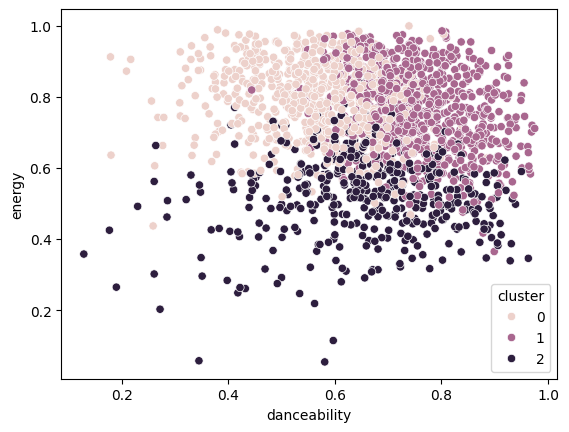

In [41]:
sns.scatterplot(data=df, x='danceability', y='energy', hue='cluster')

The clustering analysis identified three groups of songs:
- Cluster 0: highly energetic songs with low to medium danceability
- Cluster 1: medium to highly energetic songs with medium to high danceability
- Cluster 2: songs with moderate energy and a wide range of danceability

<Axes: xlabel='valence', ylabel='energy'>

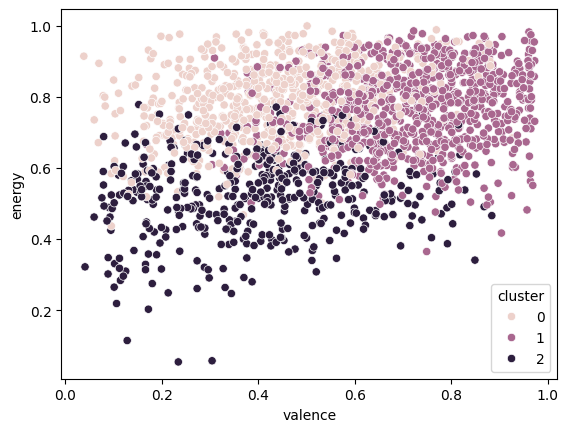

In [42]:
sns.scatterplot(data=df, x='valence', y='energy', hue='cluster')

The clustering analysis identified three groups of songs:
- Cluster 0: highly energetic songs with lower valence (more negative mood)
- Cluster 1: highly energetic songs with higher valence (more positive mood)
- Cluster 2: songs with moderate energy and relatively low valence

## Summary Clustering:
The cluster analysis shows that songs can be meaningfully grouped based on their audio features. The identified clusters differ particularly in characteristics such as energy, danceability, and valence.
The results confirm the patterns observed in the exploratory data analysis and demonstrate that these features are well suited to characterize different types of songs.